# JointPMF Data 

In [2]:
import os
from tqdm import tqdm
import sys
if not hasattr(sys.modules[__name__], "cwd_changed"):
    os.chdir(os.path.dirname(os.path.dirname(os.path.abspath(__name__))))
    sys.modules[__name__].cwd_changed = True

import warnings 
warnings.filterwarnings("ignore")
import logging
logging.getLogger('pgmpy').setLevel(logging.WARNING)


import pandas as pd
from utils.graph import dag_to_cpdag
# from metrics.graph import compare_dags
from utils.results import *
from analyses.helpers import load_results


In [3]:
import pickle
import matplotlib as mpl
import matplotlib.pyplot as plt

subset = 'jpmf_data'

def load_results(subset, base_dir= "results", ):
    global results_by_label

    with open(f'{base_dir}/pc/{subset}.pkl', 'rb') as f:
        results_pc = pickle.load(f)
    
    with open(f'{base_dir}/pc_gsq/{subset}.pkl', 'rb') as f:
        results_pc_gsq = pickle.load(f)
    

    with open(f'{base_dir}/ges/{subset}.pkl', 'rb') as f:
        results_ges = pickle.load(f)
    
    with open(f'{base_dir}/hc/{subset}.pkl', 'rb') as f:
        results_hc = pickle.load(f)

    with open(f'{base_dir}/ea_fg/{subset}.pkl', 'rb') as f:
        results_ea_fg = pickle.load(f)

    with open(f'{base_dir}/ea_hc/{subset}.pkl', 'rb') as f:
        results_ea_hc = pickle.load(f)
        
    with open(f'results/ea_ues/{subset}.pkl', 'rb') as f:
        results_ea_ues = pickle.load(f)

    with open(f'results/ea_ies/{subset}.pkl', 'rb') as f:
        results_ea_ies = pickle.load(f)
    
    with open(f'results/ea_fes/{subset}.pkl', 'rb') as f:
        results_ea_fes = pickle.load(f)


    results_by_label = {
        "PC": results_pc,
        "PC-GSQ": results_pc_gsq,   
        "GES": results_ges,
        "HC": results_hc,
        "EA-HC": results_ea_hc,
        "EA-Base": results_ea_ues,
        "EA-IES": results_ea_ies,
        "EA-FES": results_ea_fes,
        "EA-FG": results_ea_fg,
        # "NOTEARS": results_notears,
        }



mpl.rcParams.update({
    'font.family'         : 'serif',       # Computer Modern — the default LaTeX font
    'font.size'           : 12,            # body text size (most journals use 10 pt)
    'axes.labelsize'      : 12,            # axis-label size matches body text
    'xtick.labelsize'     : 12,             # tick labels one point smaller
    'ytick.labelsize'     : 12,
    'legend.fontsize'     : 12,             # legend text one point smaller
    'axes.prop_cycle'     : mpl.cycler('color', [   # Okabe–Ito colorblind-safe palette
        '#0072B2', '#D55E00', '#009E73',
        '#E69F00', '#CC79A7', '#56B4E9',
    ]),
    'lines.linewidth'     : 1.5,           # slightly thicker for print clarity
    'axes.linewidth'      : 0.8,           # thinner axis frame
    'xtick.direction'     : 'in',          # inward ticks — journal standard
    'ytick.direction'     : 'in',
    'xtick.minor.visible' : True,          # show minor ticks
    'ytick.minor.visible' : True,
    'xtick.major.size'    : 4,             # longer than the 3.5 default
    'ytick.major.size'    : 4,
    # 'xtick.minor.size'    : 2,             # half of major — proportional
    # 'ytick.minor.size'    : 2,
    'xtick.major.width'   : 0.8,           # match axes.linewidth
    'ytick.major.width'   : 0.8,
    'xtick.minor.width'   : 0.6,           # thinner for visual hierarchy
    'ytick.minor.width'   : 0.6,
    'lines.markersize'    : 4,             # smaller markers for print scale
    'errorbar.capsize'    : 3,             # visible end-caps (default is 0)
    # 'axes.xmargin'        : 0.02,          # hug the data (default is 0.05)
    # 'axes.ymargin'        : 0.02,
    'legend.frameon'      : False,         # no legend box
    'savefig.bbox'        : 'tight',       # tight bounding box by default
    'savefig.dpi'         : 600,           # publication-quality resolution
    **(                                    # LaTeX if installed, else fallback
        {'text.usetex'        : True,              # real LaTeX for all text
         'text.latex.preamble': r'\usepackage{amsmath} \usepackage{amssymb}',
         'pgf.texsystem'     : 'pdflatex',         # consistent PGF export
         'pgf.rcfonts'       : False}               # let LaTeX control fonts
        if __import__('shutil').which('latex') else
        {'text.usetex'        : False,             # no TeX install found
         'mathtext.fontset'  : 'cm'}               # Computer Modern via mathtext
    ),
})

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# subset = "jpmf_grid"

def violin_grid_2x3(
    df,
    metrics,            # dict: panel_label -> (column_name, y_label)
    alg_order=None,
    filter_dict=None,   # e.g. {"n_nodes": 50, "p_noise": 0.1, "n_xor": 10}
    figsize=(10, 7),
):
    d = df.copy()

    # optional filtering (pick a slice like the paper often does)
    if filter_dict:
        for k, v in filter_dict.items():
            d = d[d[k] == v]

    # keep only needed columns
    needed = ["Algorithm"] + [col for col, _ in metrics.values()]
    d = d[needed].copy()

    # numeric coercion for metrics
    for col, _ in metrics.values():
        d[col] = pd.to_numeric(d[col], errors="coerce")
    d = d.dropna()

    # order
    if alg_order is None:
        alg_order = sorted(d["Algorithm"].unique())

    fig, axes = plt.subplots(2, 3, figsize=figsize)
    axes = axes.ravel()

    for ax, (panel_letter, (col, ylab)) in zip(axes, metrics.items()):
        sns.violinplot(
            data=d,
            x="Algorithm",
            y=col,
            order=alg_order,
            ax=ax,
            inner="box",   # gives that little box/whisker inside
            cut=0,
            linewidth=1,
        )
        ax.set_xlabel("")
        ax.set_ylabel(ylab)
        # ax.set_ylim(0, 1.05)
        ax.tick_params(axis="x", rotation=0)

        # panel letter like A, B, C, D
        ax.text(-0.12, 1.02, panel_letter, transform=ax.transAxes,
                fontsize=14, fontweight="bold", va="bottom")

    plt.tight_layout()
    return fig, axes


load_results(subset)
long_df = build_long_metrics(results_by_label)
# long_df = long_df[long_df[""]]



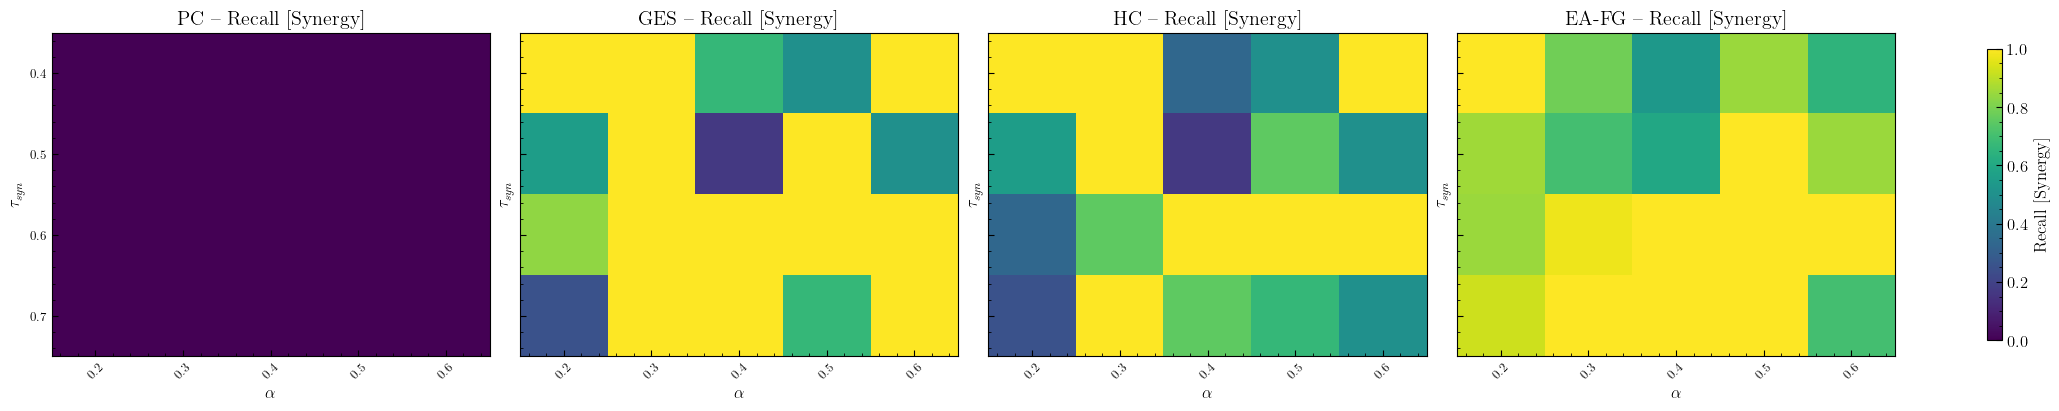

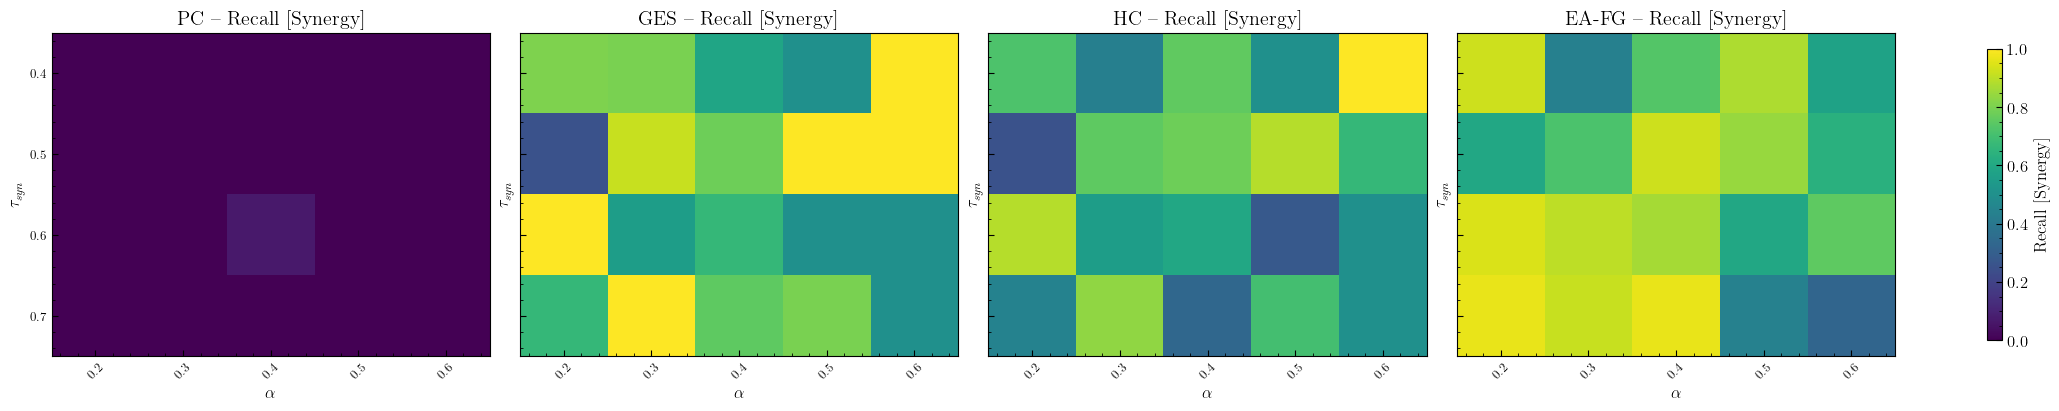

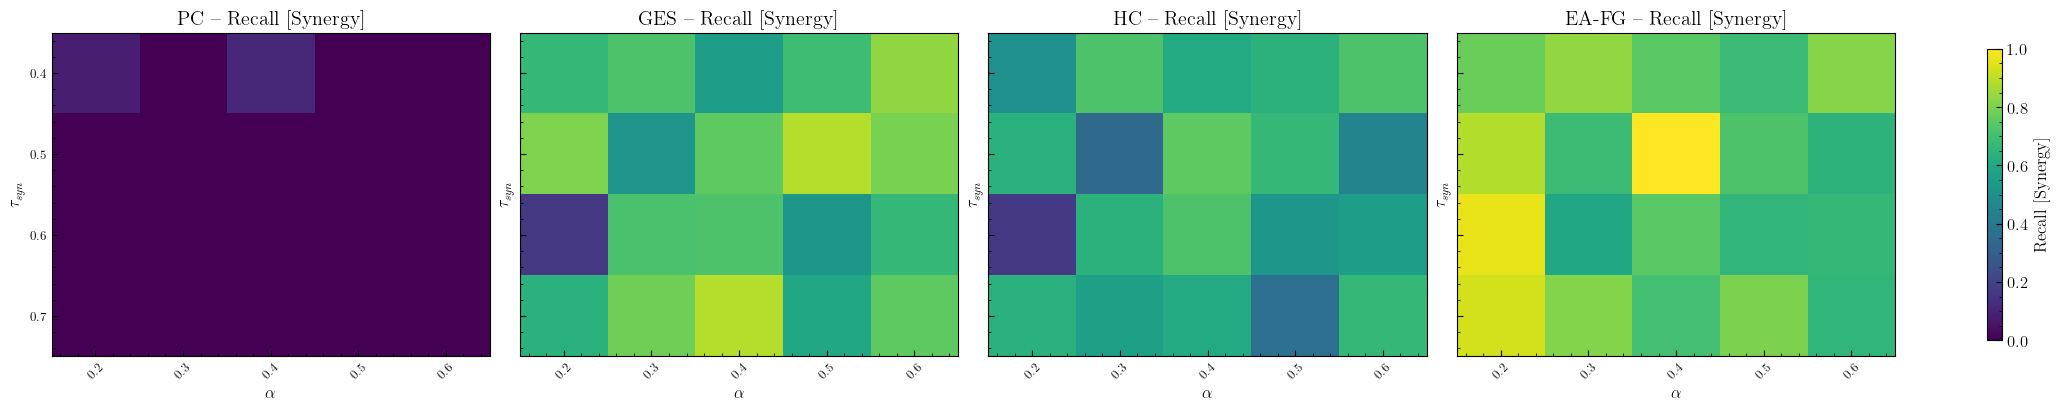

In [77]:
# metrics = ["SHD [Skeleton]", "Precision [Skeleton]", "Recall [Skeleton]", "F1 [Skeleton]"]

plot_results = {k: results_by_label[k] for k in ["PC", "GES", "HC", "EA-FG"]}
sub_df = build_long_metrics(plot_results)

sub_df = sub_df[sub_df["Total (SC)"] > 0]
sub_df = sub_df[sub_df["pair_probs"] == 0.7]

metric = "Recall [Synergy]"
x_col = "target_mi"
y_col = "syn_cutoff"


filters = [("num_vars", 10), ("num_vars", 20), ("num_vars", 30)]

# filters = [("pair_probs", )]
i = 1
for filter in filters:
    filter_col, filter_val = filter
    fig, axes = plot_final_heatmap(
        sub_df,
        ncols=5,
        # subset_metrics=[metric, x_col, y_col, filter_col],
        plot_metric=metric,
        x_col=x_col,
        aggfunc="mean",
        filter=(filter_col, filter_val),
        y_col=y_col,
    )  
    for a in axes:
        # for a in ax:
        a.set_ylabel(r"$\tau_{syn}$")
        a.set_xlabel(r"$\alpha$")
        labels = [0.20, 0.30, 0.40, 0.50, 0.60]
        a.set_xticks(range(len(labels)))
        a.set_xticklabels(labels)
            
    plt.savefig(f"Figures/jpmfData/Fig1_{i}.png", dpi=600, bbox_inches='tight')
    i += 1
#    

In [65]:
target_values = long_df["target_mi"].unique()
target_values

array([0.31699250014423125, 0.4754887502163468, 0.6339850002884625,
       0.792481250360578, 0.9509775004326936], dtype=object)

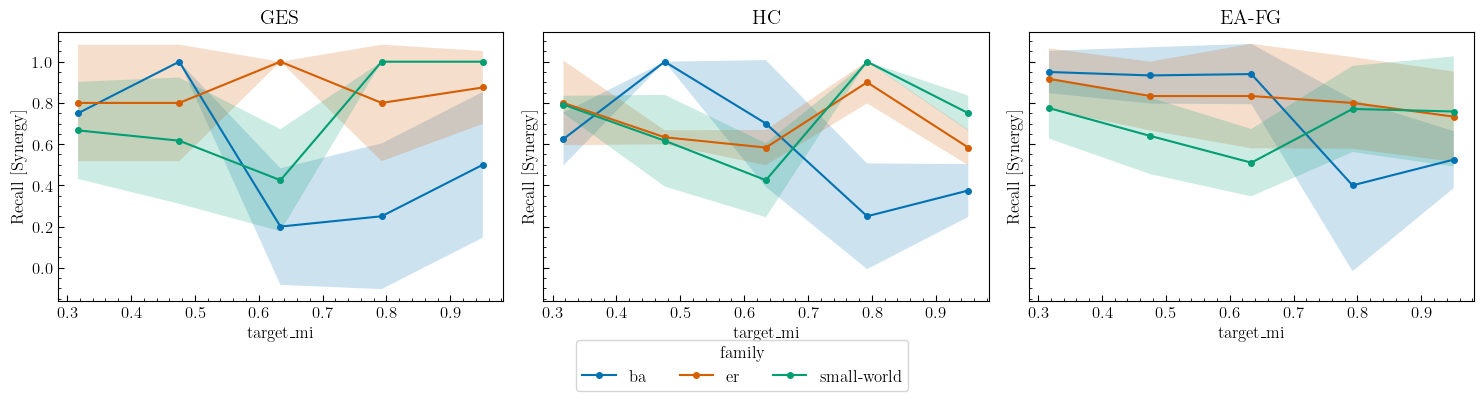

In [106]:
## Fig2 (Line plot zooming in on higher synergy cutoff values)

plot_results = {k: results_by_label[k] for k in ["GES", "HC", "EA-FG"]}
sub_df = build_long_metrics(plot_results)
sub_df = sub_df[sub_df["Total (SC)"] > 0]

sub_df = sub_df[sub_df["pair_probs"] == 0.6]
sub_df = sub_df[sub_df["num_vars"] == 30]
sub_df = sub_df[sub_df["syn_cutoff"] >= 0.6]

fig, ax = plot_final_metric_vs_x(
    sub_df,
    metric_col="Recall [Synergy]",
    x_col="target_mi",
    by="family",
    # x_label=f"$n$",
    # y_label=metric,
    # alg_order=["PC", "GES", "HC", "EA-FG"],
    # figsize=(10, 7)
)

plt.savefig(f"Figures/jpmfData/Fig2_1.png", bbox_inches='tight')
# fig
# ax


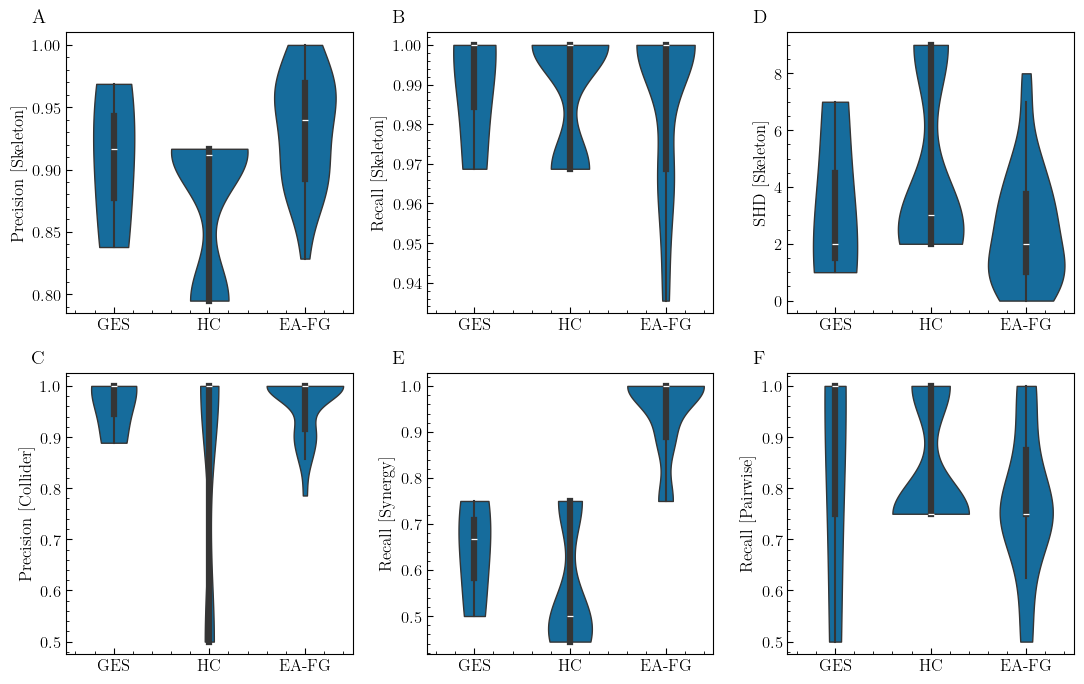

In [116]:
plot_results = {k: results_by_label[k] for k in ["GES", "HC", "EA-FG"]}
sub_df = build_long_metrics(plot_results)
sub_df = sub_df[sub_df["Total (SC)"] > 0 & (sub_df["Total (PW)"] > 0)]

metrics = {
    "A": ("Precision [Skeleton]", "Precision [Skeleton]"),
    "B": ("Recall [Skeleton]", "Recall [Skeleton]"),
    "D": ("SHD [Skeleton]", "SHD [Skeleton]"),
    "C": ("Precision [Collider]", "Precision [Collider]"),
    "E": ("Recall [Synergy]", "Recall [Synergy]"),
    "F": ("Recall [Pairwise]", "Recall [Pairwise]"),
}

alg_order = ["GES", "HC", "EA-FG"] 

# Example slice (optional):
filter_dict = {"syn_cutoff": 0.7, "num_vars": 30, "target_mi": target_values[0], "pair_probs": 0.5}
# filter_dict = None

fig, axes = violin_grid_2x3(
    sub_df,
    metrics=metrics,
    alg_order=alg_order,
    filter_dict=filter_dict,
    figsize=(11, 7),
)

plt.savefig(
    f"Figures/jpmfData/Fig3_1.png",
    dpi=800,
)


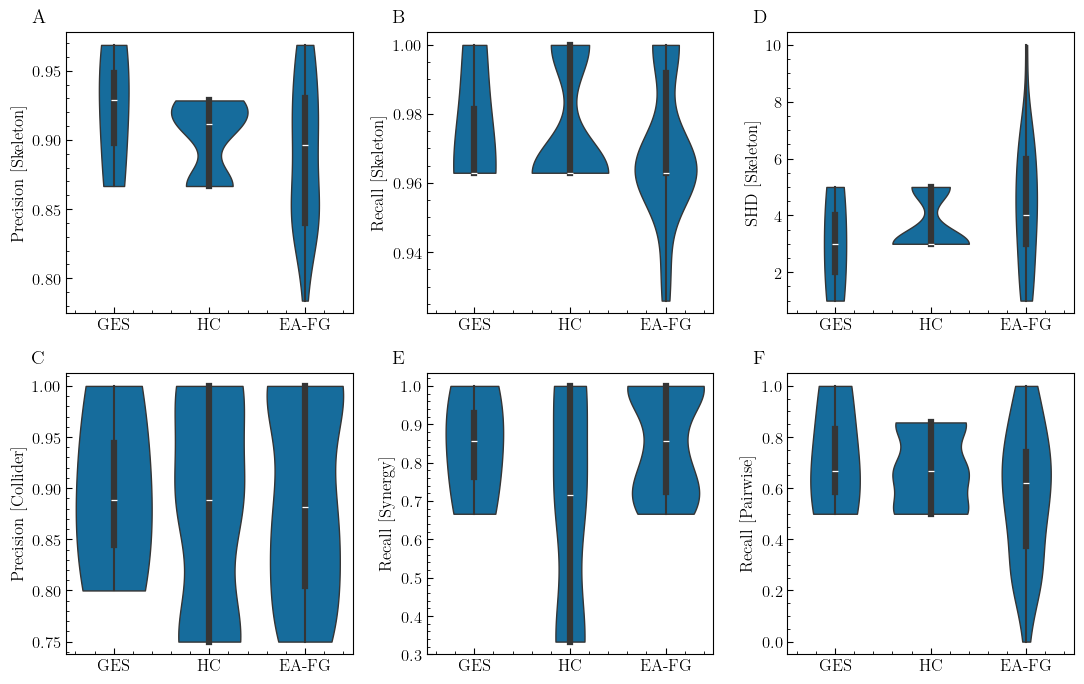

In [117]:
plot_results = {k: results_by_label[k] for k in ["GES", "HC", "EA-FG"]}
sub_df = build_long_metrics(plot_results)
sub_df = sub_df[sub_df["Total (SC)"] > 0 & (sub_df["Total (PW)"] > 0)]


metrics = {
    "A": ("Precision [Skeleton]", "Precision [Skeleton]"),
    "B": ("Recall [Skeleton]", "Recall [Skeleton]"),
    "D": ("SHD [Skeleton]", "SHD [Skeleton]"),
    "C": ("Precision [Collider]", "Precision [Collider]"),
    "E": ("Recall [Synergy]", "Recall [Synergy]"),
    "F": ("Recall [Pairwise]", "Recall [Pairwise]"),
}

alg_order = ["GES", "HC", "EA-FG"] 

# Example slice (optional):
filter_dict = {"syn_cutoff": 0.4, "num_vars": 30, "target_mi": target_values[0], "pair_probs": 0.6}
# filter_dict = None

fig, axes = violin_grid_2x3(
    sub_df,
    metrics=metrics,
    alg_order=alg_order,
    filter_dict=filter_dict,
    figsize=(11, 7),
)

plt.savefig(
    f"Figures/jpmfData/Fig3_2.png",
    dpi=800,
)


## 1.3: Tradeoffs EA+HC

In [ ]:
# long_df = build_long_metrics(results_by_label)

# metrics = {
#     "A": ("Precision [Skeleton]", "Precision [Skeleton]"),
#     "B": ("Recall [Skeleton]", "Recall [Skeleton]"),
#     "D": ("SHD [Skeleton]", "SHD [Skeleton]"),
#     "C": ("Precision [Collider]", "Precision [Collider]"),
#     "E": ("Recall [Synergy]", "Recall [Synergy]"),
#     "F": ("Recall [Pairwise]", "Recall [Pairwise]"),
# }

# alg_order = ["PC", "GES", "HC", "EA-FG"]  # or whatever you want


# # Example slice (optional):
# filter_dict = {"pair_probs": 0.5, "syn_cutoff": 0.4, "target_mi": target_values[0]}
# # filter_dict = None

# fig, axes = violin_grid_2x2(
#     long_df,
#     metrics=metrics,
#     alg_order=alg_order,
#     filter_dict=filter_dict,
#     figsize=(10, 7),
# )

# plt.savefig(
#     f"plots/{subset}/Fig7.png",
#     dpi=800,
# )


In [ ]:
# ### Metrics and Algorithms
# np.unique(long_df["Algorithm"])
long_df.columns

Index(['n_nodes', 'n_pairs', 'SHD [Skeleton]', 'Type Confusions [Adjacency]',
       'n_true [Adjacency]', 'n_pred [Adjacency]', 'TP [Adjacency]',
       'FP [Adjacency]', 'FN [Adjacency]', 'Precision [Skeleton]',
       'Recall [Skeleton]', 'F1 [Skeleton]', 'TP (Found Colliders)',
       'FP (Extra Colliders)', 'FN (Missing Colliders )',
       'TP (Synergistic Colliders Found)',
       'FN (Missing Synergistic Colliders)', 'Precision [Collider]',
       'Recall [Collider]', 'F1 [Collider]', 'Precision [Synergy]',
       'Recall [Synergy]', 'F1 [Synergy]', 'TP (Pairwise Colliders Found)',
       'FN (Missing Pairwise Colliders)', 'Precision [Pairwise]',
       'Recall [Pairwise]', 'F1 [Pairwise]', 'i', 'family', 'target_mi',
       'pair_probs', 'syn_cutoff', 'num_vars', 'TrueBIC', 'BIC', 'WallTime_s',
       'CPUTime_s', 'RSS_before_MB', 'RSS_after_MB', 'RSS_delta_MB',
       'PeakRSS_MB', 'PyAllocPeak_MB', 'Algorithm', 'run_id'],
      dtype='object')

In [ ]:
import pandas as pd

def _eval_to_df(eval_metrics):
    if eval_metrics is None:
        return None
    if isinstance(eval_metrics, pd.DataFrame):
        return eval_metrics.copy()
    if isinstance(eval_metrics, pd.Series):
        return eval_metrics.to_frame().T
    if isinstance(eval_metrics, dict):
        return pd.DataFrame([eval_metrics])
    return None

def build_long_metrics(results_by_label):
    rows = []
    for alg, results_list in results_by_label.items():
        for i, res in enumerate(results_list):
            em = getattr(res, "eval_metrics", None)
            df_em = _eval_to_df(em)
            if df_em is None or len(df_em) == 0:
                continue
            df_em = df_em.copy()
            df_em["Algorithm"] = alg
            df_em["run_id"] = i
            rows.append(df_em)
    return pd.concat(rows, ignore_index=True)

# load_results("jpmf_data")
# long_df = build_long_metrics(results_by_label)
# long_df = long_df[long_df["Total (SC)"] >= 1]


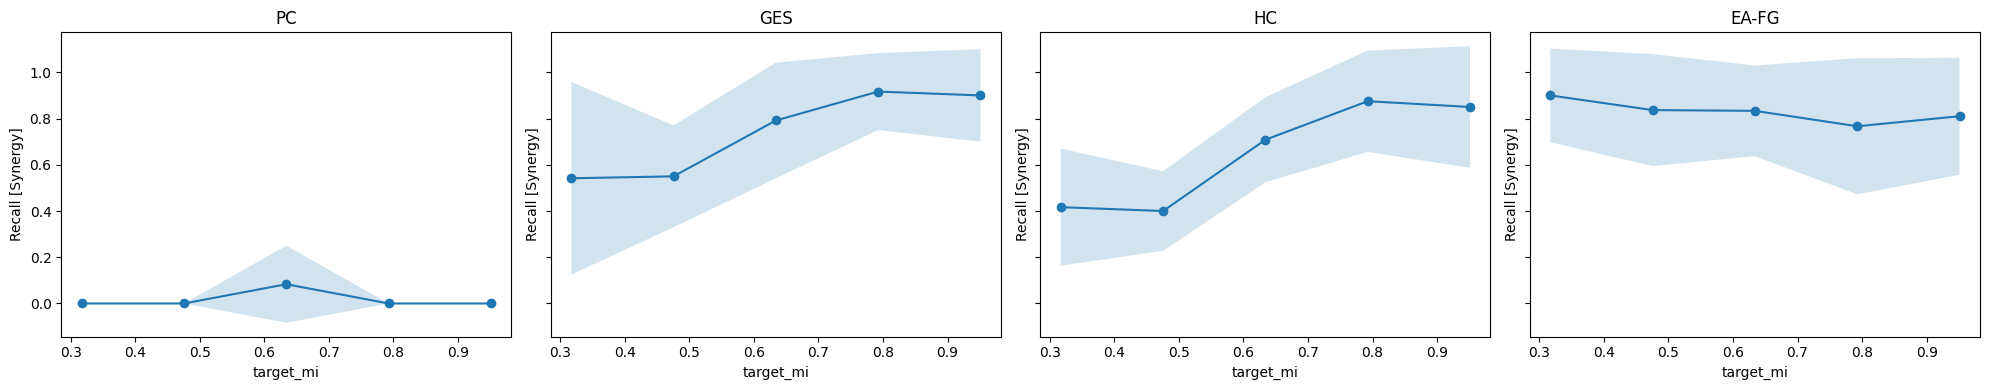

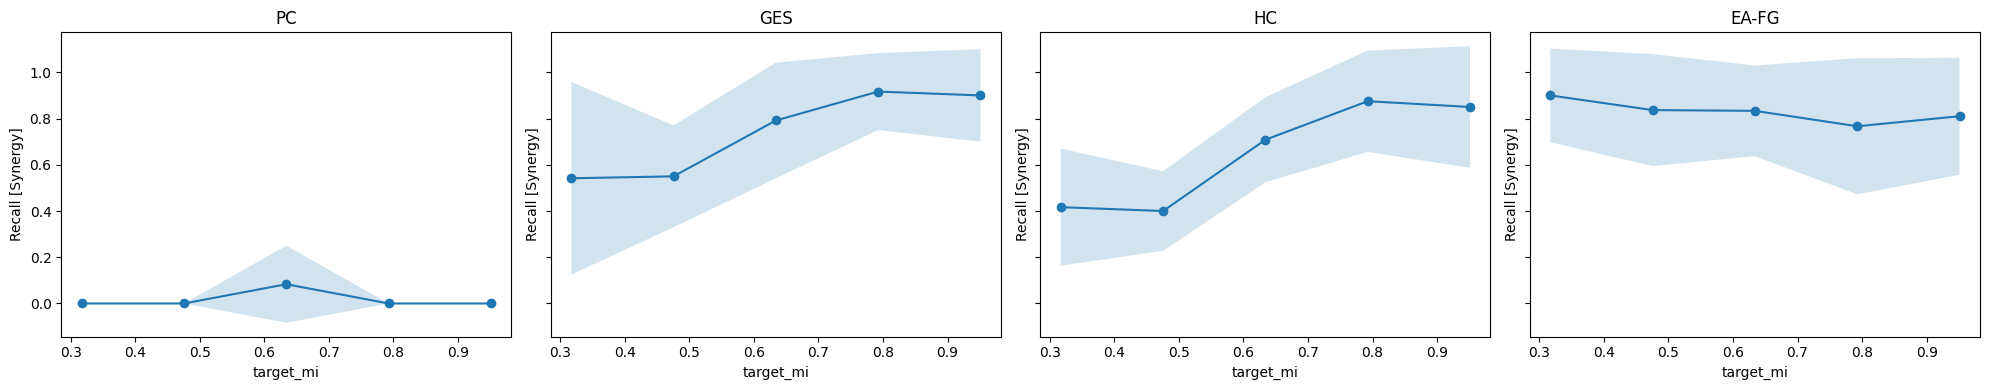

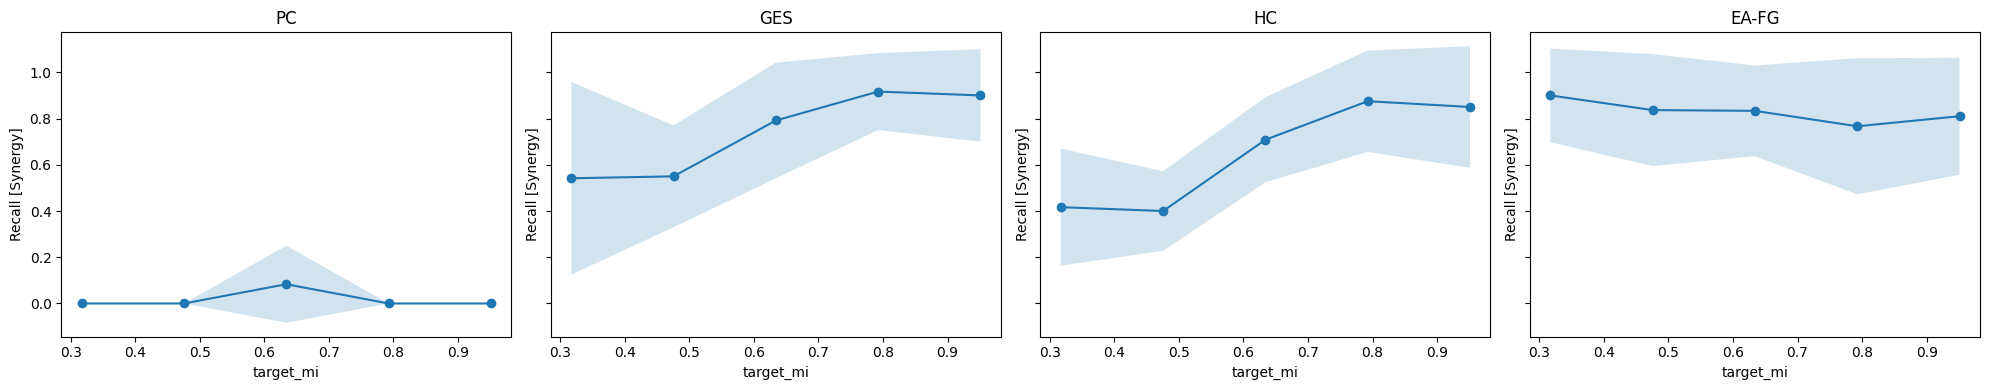

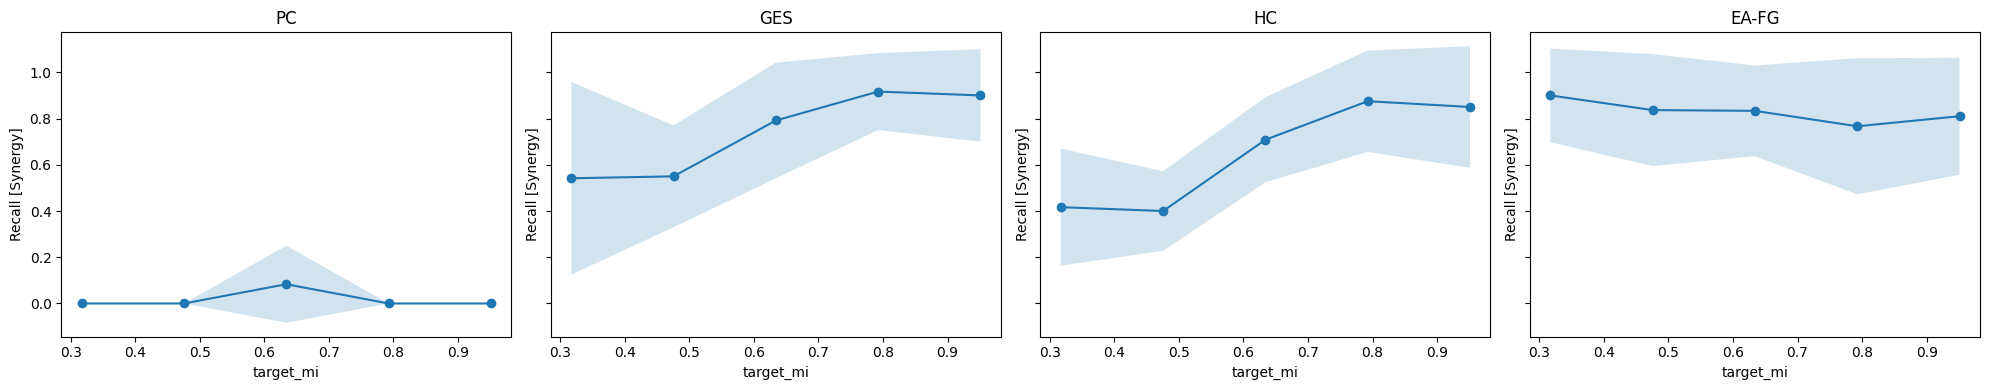

In [ ]:
# load_results("jpmf_data")
# long_df = build_long_metrics(results_by_label)
long_df = long_df[long_df["Total (SC)"] >= 1 & (long_df["Total (PW)"] >= 1)]
# six_sc = long_df[long_df["Total (SC)"] == 6]

x_col = "target_mi"
by = "syn_cutoff"
y_col = "Recall [Synergy]"

# df_subset = long_df[
#     (long_df['TP (Synergistic Colliders Found)'] > 0) &
#     (long_df['FN (Missing Synergistic Colliders)'] > 0)
# ]

filter_dict = {"num_vars":30, "pair_probs": 0.7, "family":"ba"}


for k, v in filter_dict.items():
    long_df = long_df[long_df[k] == v]

for i in long_df["syn_cutoff"].unique():
    fig, ax = plot_final_metric_vs_x(
    long_df,
    metric_col=y_col,
    x_col="target_mi",
    by=None,
    band="std",
    ylabel=y_col,
    ncols=4,
    shared_legend=True,
    legend_loc="upper center",
)

In [ ]:
# for algo in long_df["Algorithm"].unique():
#     subset_algo = long_df[long_df["Algorithm"] == algo]
#     print(f"Algorithm: {algo}")

#     plot_metric_vs_x(
#         subset_algo,
#         metric_col="Recall [Synergy]",
#         x_col="target_mi",
#         by="syn_cutoff",
#         band="std",
#         ylabel="Recall [Synergy]",
#     )